## Seasonal Component Analysis

#### Seasonal Component in Time Series

- Seasonal variations are **regular and periodic changes**

- Occur due to **natural or rhythmic forces**

- Time span: **≤ 1 year**


Seasonal variations are:

> Variations that occur regularly and periodically over a period of less than or equal to one year.



#### Examples

- Ice cream sales in summer

- Electricity demand in winter/summer

- Peak traffic → **Rush hours**

- Moderate → **Daytime**

- Low → **Midnight to early morning**


#### Where Seasonality Appears?

Seasonal variation exists when data is:

- Daily  

- Monthly  

- Quarterly  

- Yearly 

---

#### Dataset Descritpion:

The **AirPassengers dataset** is a classic real-world time series dataset that records the monthly number of international\\ airline passengers from January 1949 to December 1960, comprising a total of 144 observations. The data exhibits a clear\\ upward **trend**, reflecting the steady growth of the aviation industry over time, along with strong **seasonality**, where\\ passenger numbers consistently peak during mid-year months (typically June to August) and dip at the beginning of the year. \\An important characteristic of this dataset is its **multiplicative nature**, meaning that the magnitude of seasonal fluctuations increases as the overall level of the series rises.

---

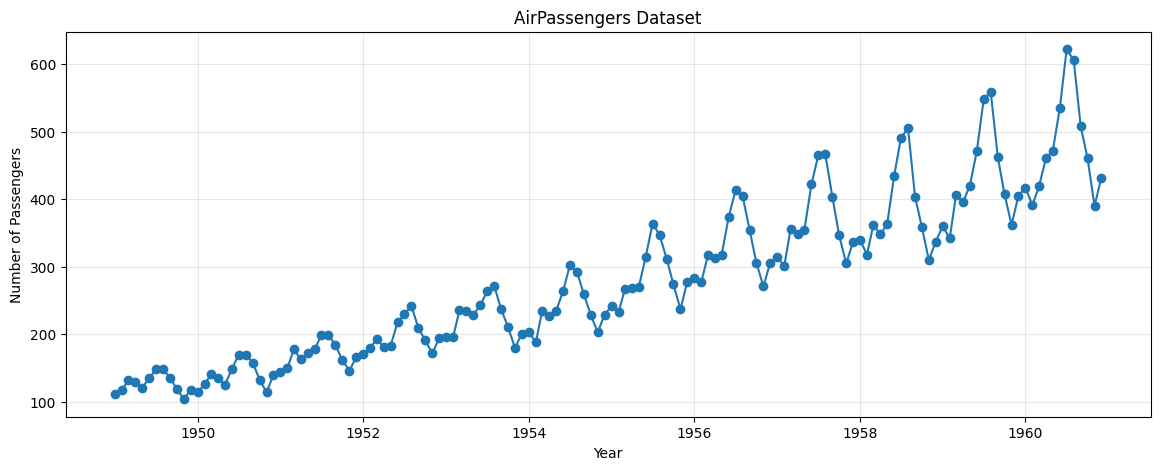

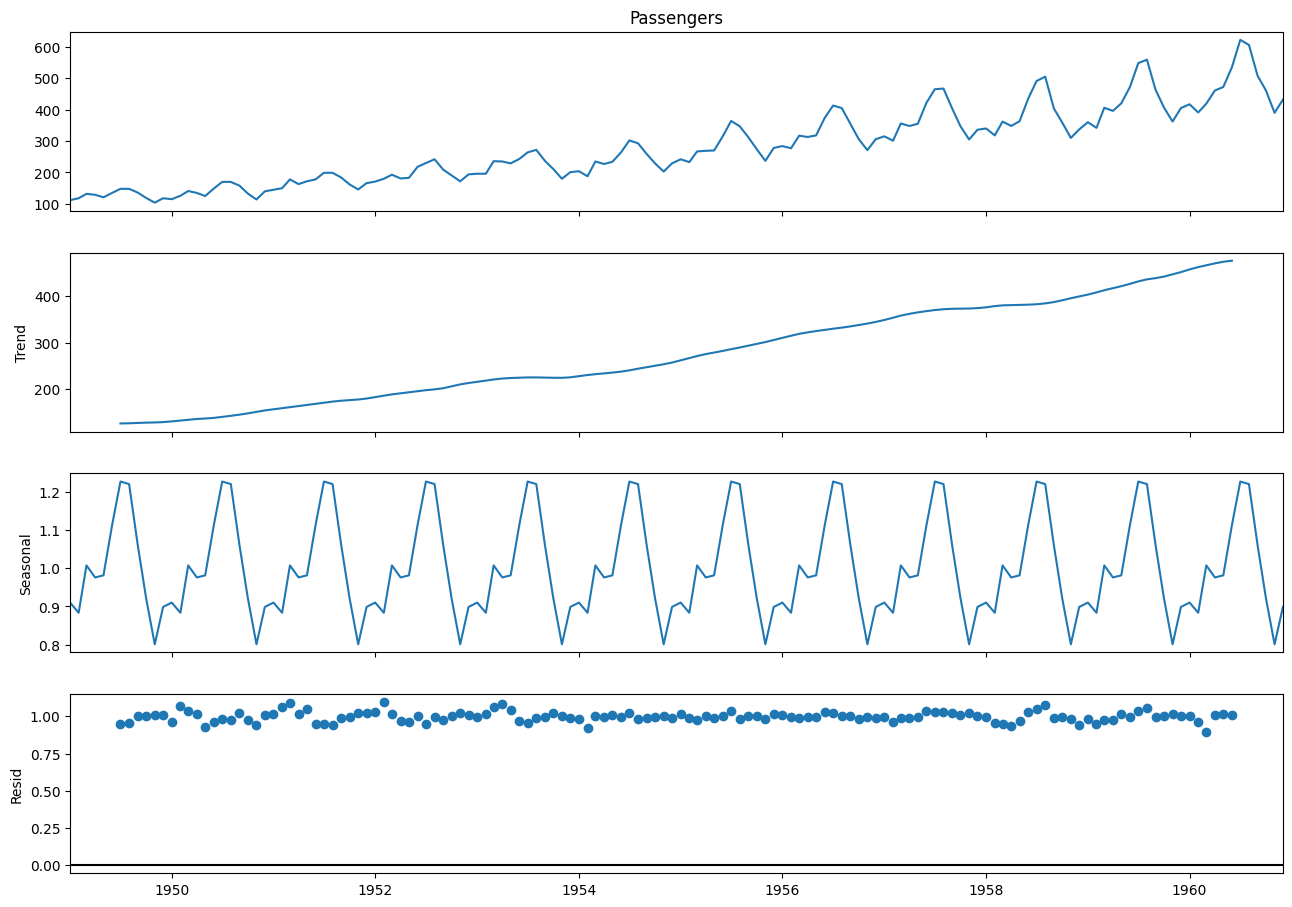

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose

# Load real dataset: Monthly airline passengers
data = get_rdataset("AirPassengers").data

# Create proper datetime index
data["time"] = pd.date_range(start="1949-01", periods=len(data), freq="MS")
data.set_index("time", inplace=True)

# Renaming column for clarity
data.rename(columns={"value": "Passengers"}, inplace=True)

# Plot original series
plt.figure(figsize=(14,5))
plt.plot(data.index, data["Passengers"], marker='o')
plt.title("AirPassengers Dataset")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True, alpha=0.3)
plt.show()

# Seasonal decomposition
result = seasonal_decompose(data["Passengers"], model="multiplicative", period=12)
fig = result.plot()
fig.set_size_inches(14, 10)
plt.show()

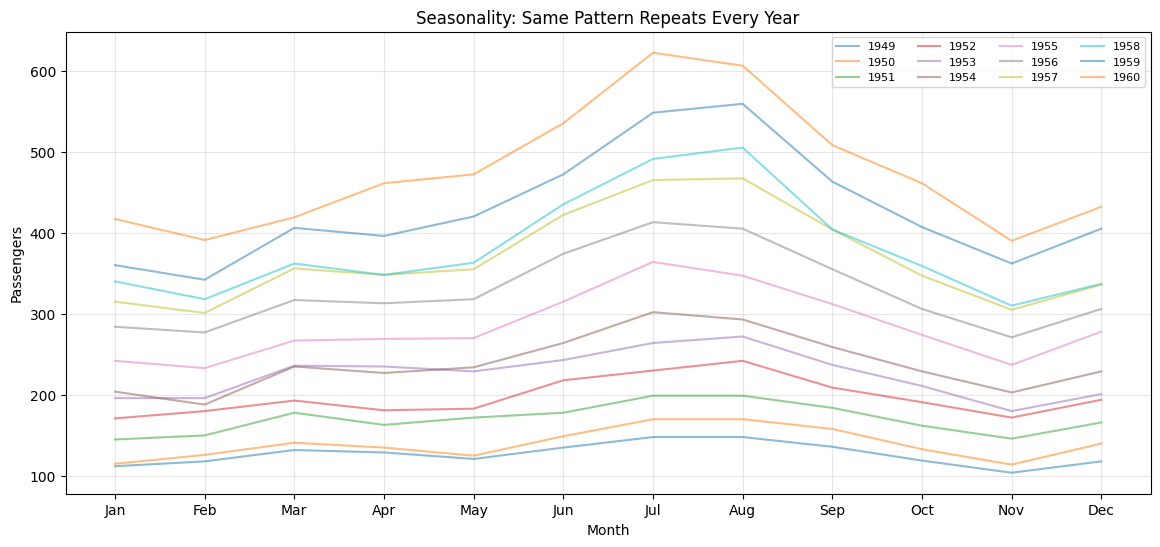

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset

# Load dataset
data = get_rdataset("AirPassengers").data

# Create datetime index
data["time"] = pd.date_range(start="1949-01", periods=len(data), freq="MS")
data.set_index("time", inplace=True)
data.rename(columns={"value": "Passengers"}, inplace=True)

# Plot each year separately to show repeating pattern
years = data.index.year.unique()

plt.figure(figsize=(14,6))

for year in years:
    subset = data[data.index.year == year]
    plt.plot(range(1,13), subset["Passengers"], label=str(year), alpha=0.5)

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Seasonality: Same Pattern Repeats Every Year")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(alpha=0.3)
plt.legend(ncol=4, fontsize=8)
plt.show()

## <u>Objectives of Seasonal Analysis</u>

#### (i) Understanding Patterns

- Identify **relative position** in each season  
- Detect **underlying forces**
- Helps in:
  - Planning  
  - Resource allocation  

#### (ii) Removing Seasonal Effects

- Helps reveal:
  - Trend  
  - Cycles  

  This process is called: **Deseasonalisation**


---

### Seasonal Index

**Seasonal Index**

- An average value used to compare actual data  

- Shows how much a period deviates from normal  


#### Seasonal Index Interpretation

- Index = 100 → Normal level  
- Index > 100 → Above normal  
- Index < 100 → Below normal 

---

## <u>Methods to Estimate Seasonality</u>

1.	Simple Average Method

2.	Ratio to Trend Method

3.	Ratio to Moving Average Method 

These methods help in understanding and measuring the **seasonal effects** present in a time series by isolating the seasonal component from trend and random variations.

All three methods aim to separate seasonality from the data:

- Moving Average → removes trend (smoothing)

- Ratio to Trend → removes trend using a fitted model

- Ratio to Moving Average → removes trend using moving averages (most preferred)

Thus, they progressively improve in accuracy and reliability for estimating seasonal indices.

---

## <u>Simple Average Method</u>

- In this method, seasonal effects are estimated by comparing the average value of each season with the overall average of the entire dataset. 

- This method is simple and easy to apply, but it assumes that the trend component is either absent or negligible, and 

- Hence may not be accurate when a strong trend is present in the data.

**Used when trend is negligible**

**Steps:**

1.	Arrange data by seasons

2.	Compute seasonal averages

3.	Compute grand average

4.	Seasonal Index:

$
S = \frac{\text{Season Avg}}{\text{Grand Avg}} \times 100
$

#### Example (Quarterly Data)

| Year | Q1 | Q2 | Q3 | Q4 |
|------|----|----|----|----|
| 1 | 10 | 20 | 30 | 40 |
| 2 | 20 | 30 | 40 | 50 |


#### Step 1: Seasonal Averages

- Q1 = (10 + 20) / 2 = 15  
- Q2 = (20 + 30) / 2 = 25  
- Q3 = (30 + 40) / 2 = 35  
- Q4 = (40 + 50) / 2 = 45  


####  Step 2: Grand Average

$(15 + 25 + 35 + 45)/4 = 30$


####  Step 3: Seasonal Indices

- Q1 = $\frac{15}{30} \times 100 = 50$  
- Q2 = $\frac{25}{30} \times 100 = 83.33$  
- Q3 = $\frac{35}{30} \times 100 = 116.67$  
- Q4 = $\frac{45}{30} \times 100 = 150$  


#### Interpretation

- Q4 → Peak season  
- Q1 → Lowest season  

---


## <u>Ratio to Trend Method</u>


- In this method, a trend line is first estimated (usually using least squares). 

- The actual values are then divided by the corresponding trend values to obtain ratios, which represent seasonal effects.

- These ratios are grouped by season (e.g., months) and averaged to compute seasonal indices.

- **This method assumes that the trend is accurately estimated.**

<br>

- *This method does not base any assumption regarding the
presence of the components in the time series.*

- *It means that we can apply this method to calculate seasonal indices even if all components namely 
trend, seasonal, cyclic and irregular variations are present in the time series.*


**Steps:**

1. Estimate trend using Least Squares  

2. Compute trend values $\hat{T}_t$  

3. Compute: 
    - Mutliplicative model: $\frac{Y_t}{\hat{T}_t} \times 100$

    <br>
    
    - Additive model: $Y_t-\hat{T}_t$

4. Group by season  

5. Average → Seasonal Index  


#### Example

| t | $Y_t$ | $T_t$ |
|--|------|------|
|1|10|12|
|2|20|18|
|3|30|28|
|4|40|38|

---

#### Step 1: Compute Ratios

- t1: $\frac{10}{12} \times 100 = 83.33$ 

<br>

- t2: $\frac{20}{18} \times 100 = 111.11$  

<br>

- t3: $\frac{30}{28} \times 100 = 107.14$  

<br>

- t4: $\frac{40}{38} \times 100 = 105.26$  

---

#### Step 2: Seasonal Indices

(Assuming each observation belongs to a different quarter)

- Q1 = 83.33 

<br>

- Q2 = 111.11  

<br>

- Q3 = 107.14  

<br>

- Q4 = 105.26  

---

#### Interpretation

- Index > 100 → Above trend  
- Index < 100 → Below trend  
---

## <u>Ratio to Moving Average Method</u>

Ratio to Moving Average is the **most commonly used method**

- This is the most widely used and reliable method for measuring seasonality. 

- It first removes the trend using moving averages (more robust than a fitted trend line), and then computes ratios of actual values to the moving average. 

- These ratios are grouped by season and averaged to obtain seasonal indices. 

- This method effectively isolates the seasonal component and reduces the influence of irregular variations.

<br>

- Preferred due to its **higher accuracy**
- Improves upon:
  - Simple Average Method  
  - Ratio to Trend Method 

Key Advantages

- Does **not require assumptions** about components  

- Works even when all components are present:
  - Trend (Tₜ)  
  - Seasonal (Sₜ)  
  - Cyclic (Cₜ)  
  - Irregular (Rₜ)  

Moving Average removes:

- Trend  
- Cyclic variations  


$$
\text{Seasonal Index} = \frac{Y_t}{\text{Moving Average}} \times 100
$$

#### Slide: Why It Works?

- Moving Average ≈ Trend + Cycle  
- So:

$$
\frac{Y_t}{MA} \approx \frac{T \times S \times C \times R}{T \times C}
$$

$$
\approx S \times R
$$
Averaging removes irregular component → gives **Seasonal Index**

---


#### Steps:
1. Compute moving average (trend-cycle)  

2. Center MA (if needed)  

3. Compute: $\frac{Y_t}{\text{Moving Average}} \times 100$

4. Group by season  

5. Average → Seasonal Index  

#### Example Data

| t | $Y_t$ |
|--|------|
|1|10|
|2|20|
|3|30|
|4|40|
|5|20|
|6|30|
|7|40|
|8|50|

---

#### Step 1: 4-Point Moving Average

| MA (between t) | Value |
|--|------|
|2–3|25|
|3–4|27.5|
|4–5|30|
|5–6|32.5|
|6–7|35|

---

#### Step 2: Centered Moving Average (CMA)

| t | CMA |
|--|------|
|3|26.25|
|4|28.75|
|5|31.25|
|6|33.75|

---

#### Step 3: Compute Ratios

| t | $Y_t$ | CMA | Ratio |
|--|------|------|------|
|3|30|26.25|114.29|
|4|40|28.75|139.13|
|5|20|31.25|64.00|
|6|30|33.75|88.89|

---

#### Step 4: Seasonal Indices

(Assuming quarterly data)

- Q1 (t=5) = 64.00  
- Q2 (t=6) = 88.89  
- Q3 (t=3) = 114.29  
- Q4 (t=4) = 139.13  

---

#### Interpretation

- Q4 → Highest demand  
- Q1 → Lowest demand  

## <u>Estimation of Trend from Deseasonalised Data</u>

When **seasonality is strong**: Trend gets **distorted** 

<br>

**Without Deseasonalisation**
Seasonal effects mix with trend  
- Leads to:
  - Incorrect trend estimation  
  - Misleading analysis  

*Result:* **Unreliable conclusions**

<br>

**Deseasonalisation**

- Remove seasonal component from data  
- Obtain **clean data** 

$$
\text{Deseasonalised Value} = \frac{Y_t \times 100}{\text{Seasonal Index}}
$$

$$\frac{Y_t}{S_t} \approx T_t \times R_t$$

*After deseasonalisation:*

- Estimate trend using:
    - Least Squares Method  
    - Moving Average Method

# Trend Estimation using Moving Average

- Moving Average is used to estimate the **Trend Component (Tₜ)**  

- It removes **seasonal and irregular variations**

- Window size = seasonal period (e.g., 4, 12)
    - In Smoothing **window size**: arbitrary (3, 5, 7…)

---

#### Continuation from above...
#### Step 5: Deseasonalisation

After finding the seasonal indices, we remove the seasonal effect from the original data.

For a multiplicative model:

$$
\text{Deseasonalised Value} = \frac{Y_t \times 100}{\text{Seasonal Index}}
$$

---

#### Seasonal Indices Obtained

- Q1 = 64.00  
- Q2 = 88.89  
- Q3 = 114.29  
- Q4 = 139.13  

Since the data are quarterly:

- t = 1, 5 → Q1  
- t = 2, 6 → Q2  
- t = 3, 7 → Q3  
- t = 4, 8 → Q4  

---

#### Step 6: Compute Deseasonalised Values

| t | Quarter | $Y_t$ | Seasonal Index | Deseasonalised Value |
|--|---------|------|----------------|----------------------|
|1|Q1|10|64.00|$\frac{10 \times 100}{64.00} = 15.63$|
|2|Q2|20|88.89|$\frac{20 \times 100}{88.89} = 22.50$|
|3|Q3|30|114.29|$\frac{30 \times 100}{114.29} = 26.25$|
|4|Q4|40|139.13|$\frac{40 \times 100}{139.13} \approx 28.75$|
|5|Q1|20|64.00|$\frac{20 \times 100}{64.00} = 31.25$|
|6|Q2|30|88.89|$\frac{30 \times 100}{88.89} = 33.75$|
|7|Q3|40|114.29|$\frac{40 \times 100}{114.29} = 35.00$|
|8|Q4|50|139.13|$\frac{50 \times 100}{139.13} \approx 35.94$|

---

#### Deseasonalised Series

| t | Deseasonalised Value |
|--|----------------------|
|1|15.63|
|2|22.50|
|3|26.25|
|4|28.75|
|5|31.25|
|6|33.75|
|7|35.00|
|8|35.94|

---

#### Interpretation

- Seasonal effects have now been removed  
- The deseasonalised data show the **underlying movement more clearly**
- We can now estimate the **trend** more reliably using:
  - Least Squares Method, or
  - Moving Average Method

---

#### Observation

Compare original and deseasonalised values:

- Original data had strong seasonal fluctuations
- Deseasonalised data are smoother
- The increasing long-term movement becomes clearer

---

#### Final Note

Thus, the procedure is:

1. Compute moving averages  
2. Estimate seasonal indices  
3. Remove seasonal effect  
4. Analyse trend from deseasonalised data

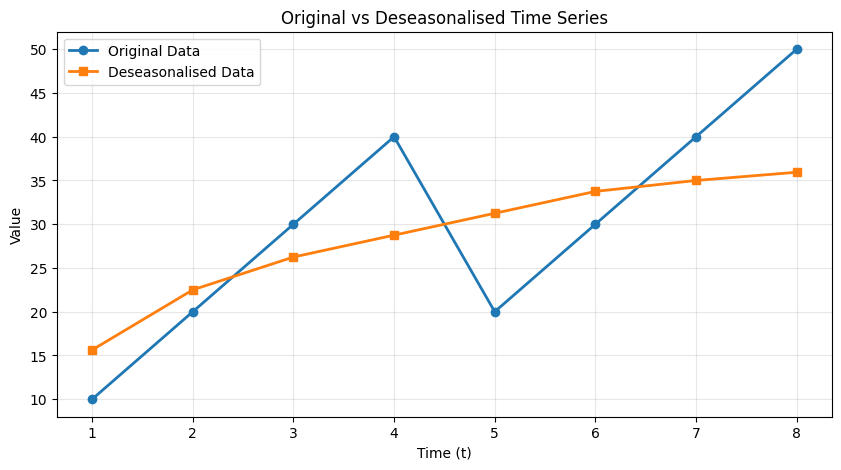

In [3]:
import matplotlib.pyplot as plt

# Time index
t = [1, 2, 3, 4, 5, 6, 7, 8]

# Original data
Y = [10, 20, 30, 40, 20, 30, 40, 50]

# Deseasonalised data
deseasonalised = [15.63, 22.50, 26.25, 28.75, 31.25, 33.75, 35.00, 35.94]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(t, Y, marker='o', linewidth=2, label='Original Data')
plt.plot(t, deseasonalised, marker='s', linewidth=2, label='Deseasonalised Data')

# Labels and title
plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.title("Original vs Deseasonalised Time Series")
plt.legend()
plt.grid(alpha=0.3)

plt.show()